## Import Library

In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import  KMeans
from sklearn.preprocessing import  StandardScaler
from sklearn.metrics import  silhouette_score

## 1. Creating data simulation

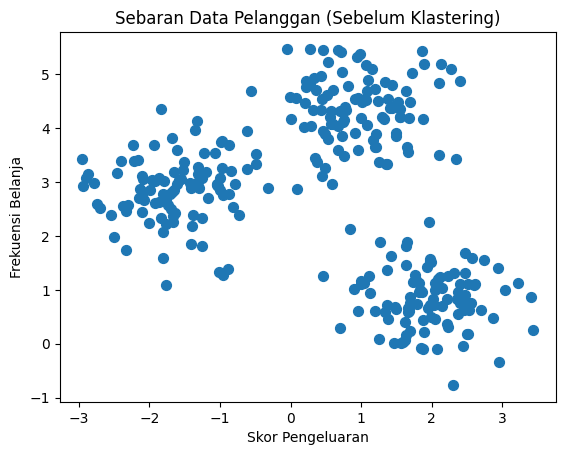

In [189]:
from sklearn.datasets import  make_blobs
X_raw, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=0)

# Konversi ke DataFrame agar mudah dibaca
df = pd.DataFrame(X_raw, columns=['Skor_Pengeluaran','Frekuensi_Belanja'])

# Visualisasi Data Mentah
plt.scatter(df['Skor_Pengeluaran'], df['Frekuensi_Belanja'], s=50)
plt.title("Sebaran Data Pelanggan (Sebelum Klastering)")
plt.xlabel("Skor Pengeluaran")
plt.ylabel("Frekuensi Belanja")
plt.show()

Sebelum standarisasi

In [190]:
# df.head()
import pandas as pd

# outliers = pd.DataFrame({
#     'Skor_Pengeluaran': [10, -10],
#     'Frekuensi_Belanja': [10, -5]
# })

# df = pd.concat([df, outliers], ignore_index=True)
df.head()

,Skor_Pengeluaran,Frekuensi_Belanja
0,0.428577,4.973997
1,1.619909,0.067645
2,1.432893,4.376792
3,-1.578462,3.034458
4,-1.658629,2.267460


## 2. Preprocessing (Standarisasi)

In [191]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print(df_scaled)

     Skor_Pengeluaran  Frekuensi_Belanja
0           -0.002888           1.461206
1            0.734455          -1.675730
2            0.618706           1.079376
3           -1.245091           0.221138
4           -1.294708          -0.269252
..                ...                ...
295         -0.263236           0.951088
296         -0.804586           0.644547
297          0.748477          -1.610789
298          0.059524           0.715663
299         -0.211927           0.118245

[300 rows x 2 columns]


## 3. Find optimal K (Elbow Method)

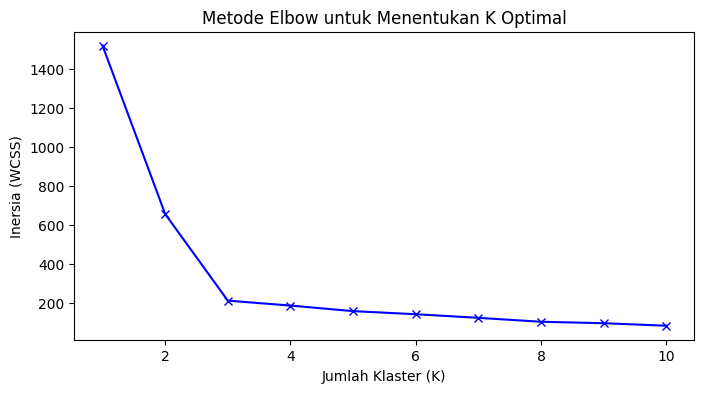

In [192]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k,init='k-means++', random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)
# Plotting Elbow
plt.figure(figsize=(8,4))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inersia (WCSS)')
plt.title('Metode Elbow untuk Menentukan K Optimal')
plt.show()

## 4. Final Clustering and visualization

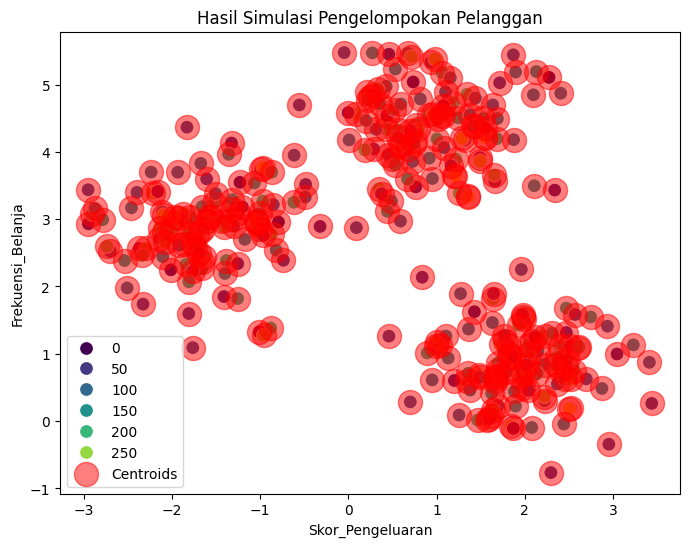

In [193]:
# Running the K-means with k=3
n_clusters = 300
kmeans_final = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# Visualisasi Hasil Klastering
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Skor_Pengeluaran', y='Frekuensi_Belanja',
hue='Cluster', palette='viridis', s=100)

# Plot Centroids
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=300, alpha=0.5, label='Centroids')
plt.title("Hasil Simulasi Pengelompokan Pelanggan")
plt.legend()
plt.show()

## 5. Validation with Silhouette Score

In [194]:
score = silhouette_score(X_scaled, df['Cluster'])
print(f'Silhoutte Score untuk k = {n_clusters}: {score:.4f}')

ValueError: Number of labels is 300. Valid values are 2 to n_samples - 1 (inclusive)